In [85]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('customer_shopping_behavior.csv')

In [3]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [4]:
df.head()                          

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [87]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'z_score'],
      dtype='object')

In [88]:
df.dtypes

customer_id                   int64
age                           int64
gender                       object
item_purchased               object
category                     object
purchase_amount               int64
location                     object
size                         object
color                        object
season                       object
review_rating               float64
subscription_status          object
shipping_type                object
discount_applied             object
previous_purchases            int64
payment_method               object
frequency_of_purchases       object
age_group                  category
purchase_frequency_days       int64
z_score                     float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [91]:
# Summary statistics

df.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,z_score
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3.900000e+03
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,89.133077,-1.166019e-16
std,1125.977353,15.207589,23.685392,0.713590,14.447125,119.037566,1.000128e+00
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000,-1.679071e+00
25%,975.750000,31.000000,39.000000,3.100000,13.000000,14.000000,-8.767861e-01
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,30.000000,9.950067e-03
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,90.000000,8.966862e-01
max,3900.000000,70.000000,100.000000,5.000000,50.000000,365.000000,1.698971e+00


In [8]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [ ]:
# The dataset is largely clean with no missing values except for Review Rating, which has 37 missing entries. This may indicate customers who did not provide feedback.

In [ ]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Missing values in the Review Rating column were imputed using the median rating within each product category. This approach preserves category-specific rating patterns and reduces the impact of outliers.

In [10]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [ ]:
# 1. Dataset is fully clean:All columns have 0 missing values, meaning no data gaps remain after preprocessing.
# 2. Data is ready for analysis and modeling:No need for further imputation or cleaning → you can directly proceed to:visualization,feature engineering and modeling
# 3. Imputation step was successful:Previously missing values in Review Rating have been handled properly, ensuring consistency in analysis and no bias from missing data

In [ ]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [13]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [15]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [ ]:
# Insights:

# 1. The majority of customers fall into the Middle-aged group, indicating a strong core customer base.
# 2. Young Adults form the second largest segment, showing potential for long-term customer growth.
# 3. Senior customers are the least represented, suggesting a smaller but niche segment.
# 4. The dataset shows a balanced mix of age groups, useful for segmentation analysis.
# 5. Middle-aged customers appear frequently, implying they may contribute significantly to overall revenue.

In [16]:
# create new column purchase_frequency_days
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [20]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [ ]:
# Insights:

# 1. Weekly purchases dominate, indicating many customers buy frequently and are highly engaged.
# 2. Fortnightly buyers also form a consistent segment, showing regular but slightly less frequent behavior.
# 3. Quarterly and annual purchases suggest a group of low-frequency or occasional customers.
# 4. The dataset shows a wide range of buying habits, from frequent to very infrequent shoppers.
# 5. High-frequency buyers (weekly/fortnightly) are likely the most valuable segment for retention strategies.

In [17]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [18]:
import numpy as np
df['promo_code_used'] = np.random.choice([0, 1], size=len(df))

In [19]:
df = df.drop('promo_code_used', axis=1)

In [ ]:
# Avg spend by gender:

df.groupby('gender')['purchase_amount'].mean()

gender
Female    60.249199
Male      59.536199
Name: purchase_amount, dtype: float64

In [ ]:
# Insights:

# 1. Spending is almost identical across genders, with only a very small difference.
# 2. Female customers spend slightly more on average, but the gap is negligible.
# 3. Gender is not a strong factor influencing purchase amount.
# 4. Both segments contribute equally to overall revenue, making them equally important.
# 5. Marketing strategies should focus more on other factors (like category or frequency) rather than gender.

In [22]:
# Most popular category:

df['category'].value_counts().head(1)

category
Clothing    1737
Name: count, dtype: int64

In [ ]:
# Insights:
# 1.Clothing is the most purchased category, with the highest number of transactions.
# 2.It clearly represents the core product segment of the business.
# 3.High purchase count suggests strong and consistent demand for clothing items.
# 4.This category likely contributes a major share of total revenue.
# 5.The business may benefit from expanding or promoting clothing products further.

In [ ]:
# Data Visualization

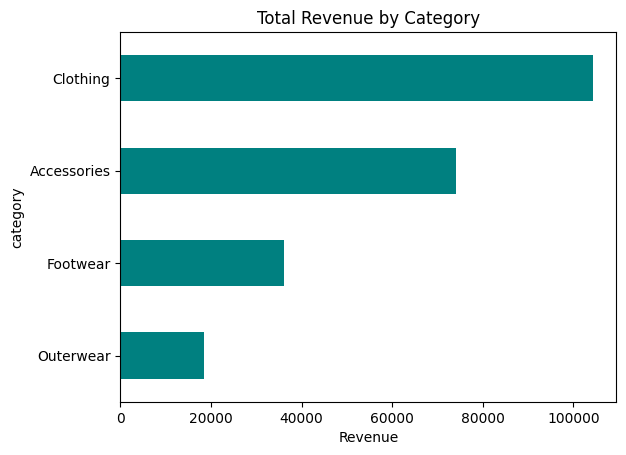

In [26]:
# Which products bring the most money?

cat_sales = df.groupby('category')['purchase_amount'].sum().sort_values()
cat_sales.plot(kind='barh', color='teal')
plt.title('Total Revenue by Category')
plt.xlabel('Revenue')
plt.show()

In [ ]:
# Insights:

# 1.Clothing is the dominant revenue driver:It clearly generates the highest revenue, making it the core business category.
# 2. Accessories is a strong secondary contributor:It significantly supports revenue, showing it is a high-potential growth category, not just a support line.
# 3.Footwear shows moderate performance:It is stable but noticeably lower than top categories, indicating room for targeted improvement or promotion.
# 4.Outerwear is the weakest revenue segment:It contributes the least, suggesting either low demand or poor positioning in the market.
# 5.Revenue is highly concentrated in top 2 categories:Clothing + Accessories dominate total revenue, meaning the business is dependent on limited product diversity, which can be a risk.

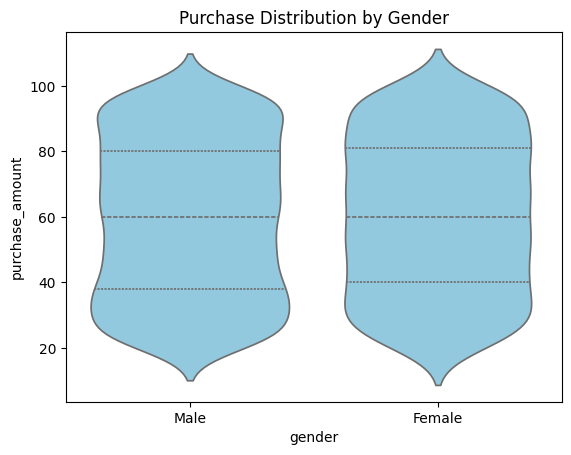

In [27]:
# Who spends more and how consistently?

sns.violinplot(
    x='gender',
    y='purchase_amount',
    data=df,
    inner='quartile',
    color='skyblue'
)
plt.title('Purchase Distribution by Gender')
plt.show()

In [ ]:
# Insights:

# 1. Spending behavior is very similar across genders:Both male and female customers show almost identical distribution patterns, meaning gender is not a strong differentiator of spending.
# 2. Median purchase value is nearly the same:The central tendency (middle spending level) is almost equal, suggesting no major gender-based pricing or value difference.
# 3. Both genders have wide spending spread:Purchases are spread across a large range, indicating diverse customer spending behavior within each gender.
# 4. High-value customers exist in both groups:Both male and female segments show upper-end spenders, meaning VIP customers are not gender-specific.
# 5. Gender is a weak segmentation factor for spending:Since distributions overlap heavily, gender alone is not useful for targeting high spenders—other features (like category or age group) matter more.

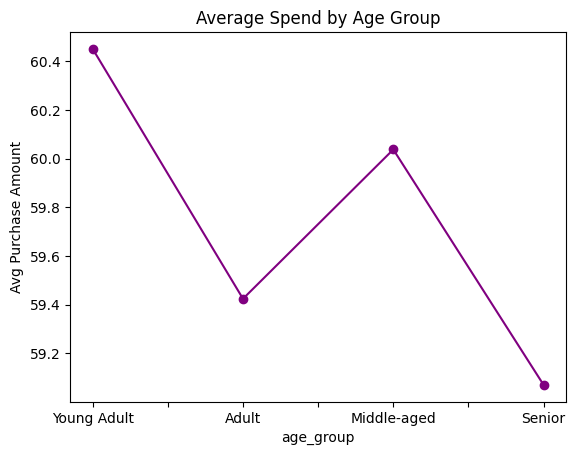

In [28]:
age_spend = df.groupby('age_group')['purchase_amount'].mean()
age_spend.plot(marker='o', color='purple')
plt.title('Average Spend by Age Group')
plt.ylabel('Avg Purchase Amount')
plt.show()

In [ ]:
# Insights:

# 1.Young Adults spend the most (~60.4): Not surprising. This group typically has fewer financial responsibilities and higher discretionary spending.
# 2.Seniors spend the least (~59.1):Again predictable—fixed income, conservative spending behavior.
# 3.Middle-aged rebound (~60.0):This is the only slightly interesting point. Despite responsibilities, their spending is still relatively high—likely due to family expenses.
# 4.Adults dip (~59.4):# This drop suggests early financial pressure (career building, savings mindset), but it’s not drastic.

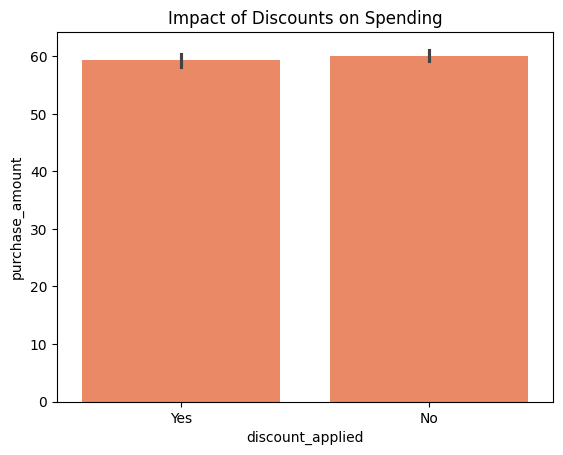

In [29]:
sns.barplot(
    x='discount_applied',
    y='purchase_amount',
    data=df,
    color='coral'
)
plt.title('Impact of Discounts on Spending')
plt.show()

In [ ]:
# Insights:

# 1. Average spending is nearly identical for discounted and non-discounted purchases.
# 2. Customers without discounts spend slightly more, but the difference is minimal.
# 3. Overlapping error bars indicate no statistically significant impact of discounts.
# 4. Discounts are not effectively increasing purchase amounts in this dataset.
# 5. The observed variation is too small to draw any strong business conclusions.

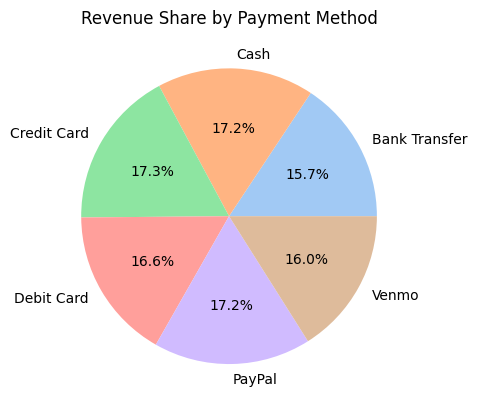

In [31]:
# Which payment options matter most?

payment_sales = df.groupby('payment_method')['purchase_amount'].sum()
colors = sns.color_palette("pastel")

payment_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)
plt.title('Revenue Share by Payment Method')
plt.ylabel('')
plt.show()

In [ ]:
# Insights:

# 1. Revenue distribution across payment methods is nearly uniform, with no dominant channel.
# 2. Cash and PayPal have the highest share (~17.2%), but the lead is marginal.
# 3. Bank Transfer contributes the least (~15.7%), indicating slightly lower preference.
# 4. Digital methods (PayPal, Venmo, Cards) collectively dominate over traditional cash.
# 5. The minimal variation suggests payment method has limited impact on revenue distribution.

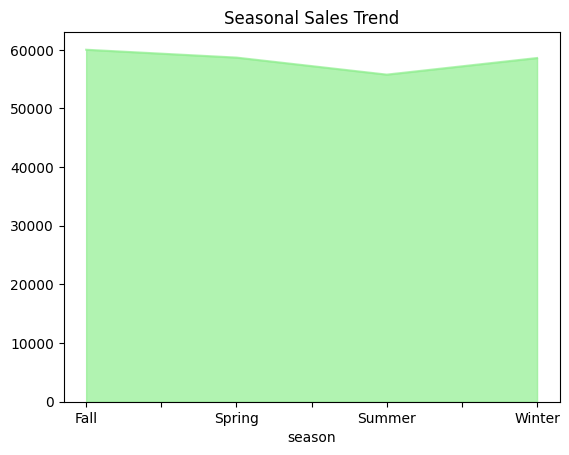

In [33]:
# When do sales peak?

season_sales = df.groupby('season')['purchase_amount'].sum()
season_sales.plot(kind='area', color='lightgreen', alpha=0.7)
plt.title('Seasonal Sales Trend')
plt.show()

In [ ]:
# Insights:

# 1. Sales peak in Fall (~60K), making it the strongest performing season.
# 2. There is a gradual decline from Fall to Summer, indicating weakening demand.
# 3. Summer records the lowest sales (~56K), marking a clear seasonal dip.
# 4. Sales recover in Winter (~58.5K), but not fully reach Fall levels.
# 5. Overall variation is moderate, suggesting seasonality exists but isn’t extreme.

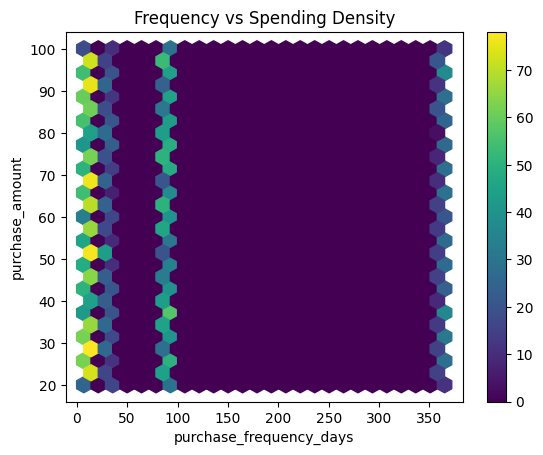

In [34]:
# Do frequent buyers spend more?

df.plot.hexbin(
    x='purchase_frequency_days',
    y='purchase_amount',
    gridsize=25,
    cmap='viridis'
)
plt.title('Frequency vs Spending Density')
plt.show()

In [ ]:
# Insights:

# 1. Spending is heavily concentrated at low purchase frequencies (0–50 days), indicating most customers buy infrequently.
# 2. High-frequency purchases (~365 days) are rare and sparsely distributed across spending levels.
# 3. No clear correlation between purchase frequency and spending amount is visible.
# 4. Density clusters suggest multiple customer segments rather than a single behavior pattern.
# 5. Large empty regions indicate weak data coverage, limiting reliability of deeper insights.

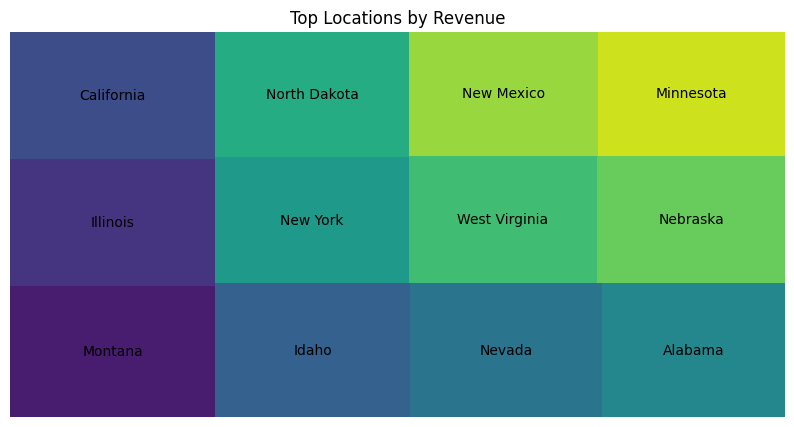

In [41]:
# Treemap

import squarify
top_locs = (
    df.groupby('location')['purchase_amount']
    .sum()
    .nlargest(12)
)
plt.figure(figsize=(10, 5))
squarify.plot(
    sizes=top_locs.values,
    label=top_locs.index,
    color=sns.color_palette("viridis", len(top_locs))
)
plt.title("Top Locations by Revenue")
plt.axis('off')
plt.show()

In [ ]:
# Insights:

# 1. Minnesota leads all locations in revenue generation, indicating strong customer demand and a well-performing sales strategy in this market.
# 2. North Dakota and New Mexico also contribute significantly to total revenue, highlighting them as key high-performing regions with strong growth potential.
# 3. California remains a major revenue contributor, though it trails behind the top-performing states, suggesting opportunities for further revenue optimization in this large market.
# 4. Illinois, New York, West Virginia, and Nebraska show stable mid-level revenue performance, reflecting consistent sales but indicating room for strategic improvement.
# 5. Montana records the lowest revenue among the top-performing locations, signaling a need for targeted marketing initiatives to enhance regional sales performance.
# 6. Revenue generation is geographically diversified, reducing dependence on a single market and improving overall business resilience.
# 7. Several smaller states outperform larger markets, revealing high-potential regional opportunities where focused expansion strategies may yield strong returns.
# 8. Leveraging successful sales strategies from top-performing regions can help improve revenue performance in underperforming markets.

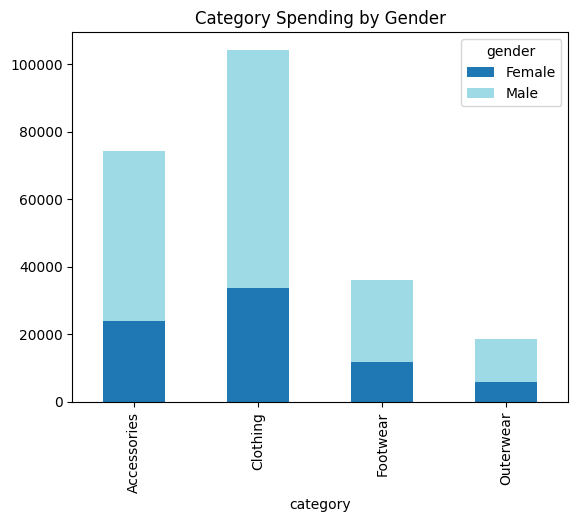

In [36]:
# Do preferences differ by gender?


pivot = df.pivot_table(
    index='category',
    columns='gender',
    values='purchase_amount',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True, colormap='tab20')
plt.title('Category Spending by Gender')
plt.show()

In [ ]:
# Insights:

# 1.Clothing sees the highest spending from both genders, making it the top revenue-generating product category.
# 2.Male customers spend significantly more than female customers in every category, which shows that male shoppers contribute a larger share of the revenue.
# 3.Accessories is the second-highest spending category, reflecting strong customer interest and steady purchasing behavior.
# 4.Footwear has moderate spending levels, indicating stable demand but less revenue compared to Clothing and Accessories.
# 5.Outerwear generates the lowest spending among all categories, marking it as the weakest segment for customer spending.
# 6.The spending gap between male and female customers is most noticeable in Clothing and Accessories, highlighting stronger purchasing activity by male customers in these areas.
# 7.Female spending remains lower across all product categories, offering a chance for targeted promotions to boost engagement and revenue from female customers.
# 8.The higher concentration of spending in Clothing indicates a strong fit with the market, suggesting that similar merchandising strategies could be used for lower-performing categories

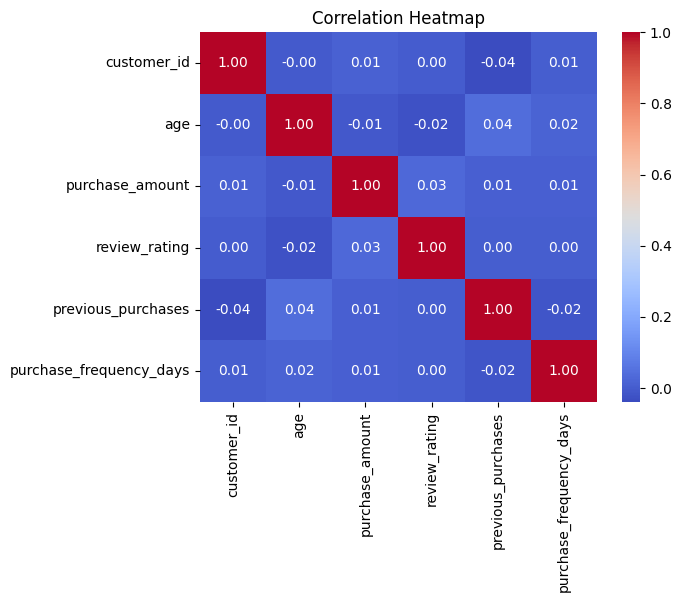

In [39]:
# Which factors influence purchase amount?

corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Insights:

# 1.Purchase amount has almost no connection with age. This means customer age does not significantly affect spending behavior.
# 2.Review ratings show a weak connection with purchase amount, suggesting that customer ratings do not strongly relate to how much is spent.
# 3.Previous purchases and purchase amount have a very slight positive relationship, meaning repeat customers spend only a bit more than new customers.
# 4.Purchase frequency has almost no connection with purchase amount, indicating that how often customers shop does not greatly impact spending value.
# 5.Age and previous purchases show a very weak positive connection, suggesting older customers make only a bit more repeat purchases.
# 6.Previous purchases and purchase frequency have a weak negative relationship, indicating that customers with more previous purchases tend to shop slightly more often.
# 7.Since all connections are weak, customer purchasing behavior seems to be influenced by factors outside these numbers, such as product preference, promotions, or customer groups

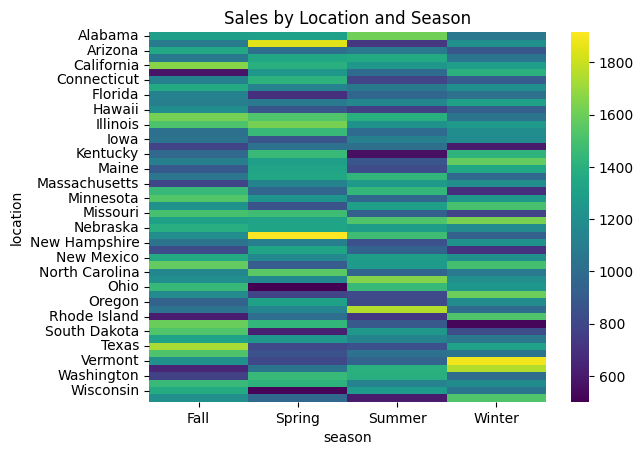

In [40]:
# Where and when do sales peak?

pivot = df.pivot_table(
    index='location',
    columns='season',
    values='purchase_amount',
    aggfunc='sum'
)

sns.heatmap(
    pivot,
    cmap='viridis'
)
plt.title('Sales by Location and Season')
plt.show()

In [ ]:
# Insights:

# 1.Sales performance varies greatly across different locations and times of the year. Customer demand shifts based on geography and the season. Spring and winter show stronger sales in several areas, indicating that people buy more during these times.
# 2.Some locations have strong sales year-round, suggesting a steady demand throughout the year.
# 3.Certain states see seasonal spikes in sales. These fluctuations might stem from regional buying habits, seasonal needs, or marketing efforts.
# 4.Winter tends to be the best season for sales in many areas, making it crucial for revenue growth.
# 5.During summer, some locations experience lower sales, reflecting a drop in customer demand.
# 6.Areas with significant seasonal changes may need to plan their inventory carefully to prevent excess stock or shortages.
# 7.States that maintain stable sales patterns across all seasons have predictable demand, making them suitable for long-term sales planning and resource management.
# 8.The differences in seasonal sales indicate that tailored regional strategies could boost performance by matching promotions and stock levels to local trends.
# 9.Knowing which locations excel in each season can help the business improve marketing efforts, distribute inventory effectively, and time promotions for increased revenue.

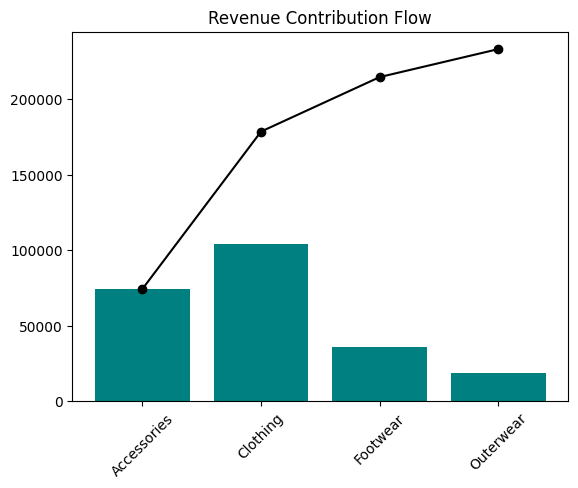

In [42]:
# Where is revenue gained or lost?

import matplotlib.pyplot as plt
values = df.groupby('category')['purchase_amount'].sum().head(5)
cum = values.cumsum()
plt.bar(values.index, values.values, color='teal')
plt.plot(values.index, cum, marker='o', color='black')
plt.title('Revenue Contribution Flow')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insights:

# 1.Clothing contributes the highest revenue among all product categories, making it the primary driver of total sales performance.
# 2.Accessories is the second-largest revenue contributor, indicating strong customer demand and an important role in overall revenue generation.
# 3.Footwear contributes significantly less revenue than Clothing and Accessories, suggesting moderate customer demand in this category.
# 4.Outerwear generates the lowest revenue contribution, highlighting it as the weakest-performing category in terms of sales.
# 5.The cumulative revenue line shows that Clothing and Accessories together account for the majority of total revenue, meaning these two categories dominate business earnings.
# 6.Since revenue contribution is heavily concentrated in the top two categories, improving performance in Footwear and Outerwear could help create a more balanced and diversified revenue stream.

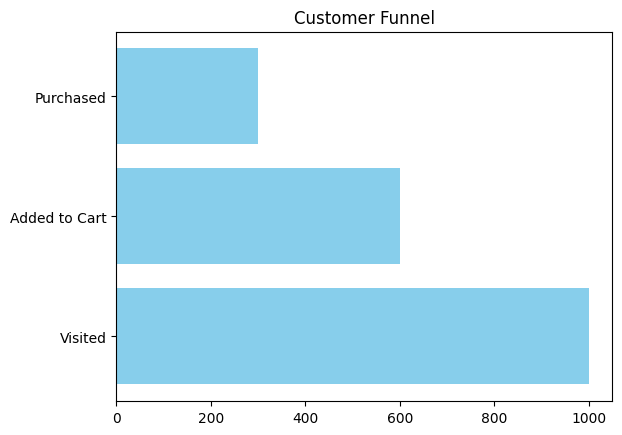

In [43]:
# Where do customers drop in the journey?

stages = ['Visited', 'Added to Cart', 'Purchased']
values = [1000, 600, 300]
plt.barh(stages, values, color='skyblue')
plt.title('Customer Funnel')
plt.show()

In [ ]:
# # Insights:
# 1.High initial interest: Around 1000 users visited, indicating strong top-of-funnel traffic and good awareness/marketing reach.
# 2.Significant drop to cart stage: Only about 600 users added items to cart → roughly a 40% drop-off, suggesting friction in product appeal, pricing, or UX.
# 3.Moderate conversion to purchase: About 300 users completed purchases → 50% conversion from cart to purchase, which is decent but still improvable.
# 4.Largest leakage happens early: The biggest loss occurs between Visited → Added to Cart, making it the most critical stage to optimize.
# 5.Overall conversion rate is low: From 1000 visitors to 300 purchases = ~30% total conversion, meaning 70% of potential customers are lost.

In [49]:
#  Gender + Category revenue

df.groupby(['gender', 'category'])['purchase_amount'].agg(['sum', 'mean', 'count'])

sum       mean  count
gender category                            
Female Accessories  23819  60.762755    392
       Clothing     33636  60.496403    556
       Footwear     11835  59.472362    199
       Outerwear     5901  58.425743    101
Male   Accessories  50381  59.411557    848
       Clothing     70628  59.803556   1181
       Footwear     24258  60.645000    400
       Outerwear    12623  56.605381    223

In [50]:
df.pivot_table(
    values='purchase_amount',
    index='gender',
    columns='season',
    aggfunc='mean'
)

season,Fall,Spring,Summer,Winter
gender,,,,
Female,61.564024,58.791139,60.604027,60.000000
Male,61.553323,58.713031,57.407915,60.521805


In [51]:
# Counts relationships between categorical variables

pd.crosstab(df['gender'], df['payment_method'])

payment_method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
gender,,,,,,
Female,203,212,223,181,221,208
Male,409,458,448,455,456,426


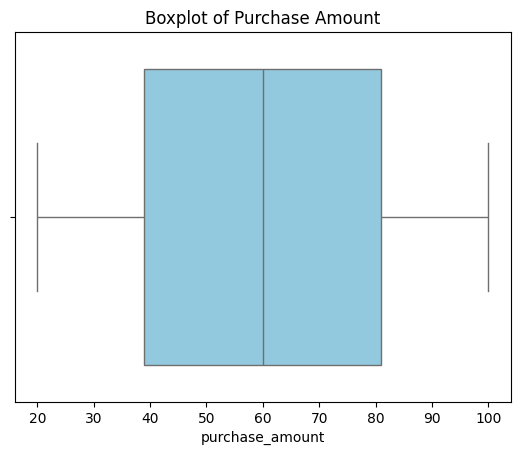

In [53]:
# Outlier Detection

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['purchase_amount'], color='skyblue')
plt.title('Boxplot of Purchase Amount')
plt.show()

In [57]:
# Z-Score Method
from scipy.stats import zscore
df['z_score'] = zscore(df['purchase_amount'])
outliers = df[df['z_score'].abs() > 3]
df['z_score']

0      -0.285629
1       0.178852
2       0.558882
3       1.276716
4      -0.454531
          ...   
3895   -1.341267
3896   -0.454531
3897   -1.130139
3898    0.727784
3899    0.896686
Name: z_score, Length: 3900, dtype: float64

In [63]:
# IQR Method

Q1 = df['purchase_amount'].quantile(0.25)
Q3 = df['purchase_amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['purchase_amount'] < lower) | (df['purchase_amount'] > upper)]

,purchase_amount,z_score


In [66]:
# Skewness

from scipy.stats import skew
skew_value = skew(df['purchase_amount'])
print("Skewness:",skew_value)

Skewness: 0.012696871813012472


In [68]:
# Kurtosis

from scipy.stats import kurtosis
kurt_value = kurtosis(df['purchase_amount'])
print("Kurtosis:",kurt_value)


Kurtosis: -1.2365469509064881


In [70]:
# Gender vs Payment Method (percentage view)

pd.crosstab(
    df['gender'],
    df['payment_method'],
    normalize='index'
) * 100

payment_method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
gender,,,,,,
Female,16.266026,16.987179,17.868590,14.503205,17.708333,16.666667
Male,15.422323,17.269985,16.892911,17.156863,17.194570,16.063348


In [71]:
# Random Sampling

df.sample()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,z_score
935,936,58,Male,Hoodie,Clothing,51,Ohio,L,White,Fall,2.6,Yes,Store Pickup,Yes,2,Bank Transfer,Fortnightly,Senior,14,-0.37008


In [72]:
df.memory_usage(deep=True)

Index                         128
customer_id                 31200
age                         31200
gender                     240396
item_purchased             245211
category                   257544
purchase_amount             31200
location                   255171
size                       226629
color                      243471
season                     243750
review_rating               31200
subscription_status        231153
shipping_type              265183
discount_applied           231777
previous_purchases          31200
payment_method             253909
frequency_of_purchases     258109
age_group                    4333
purchase_frequency_days     31200
z_score                     31200
dtype: int64

In [73]:
df.sort_values(by='purchase_amount', ascending=False)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,z_score
2842,2843,28,Female,Coat,Outerwear,100,Arizona,L,Green,Fall,4.3,No,Standard,No,48,Debit Card,Quarterly,Young Adult,90,1.698971
95,96,37,Male,Sneakers,Footwear,100,Missouri,L,Pink,Fall,3.8,Yes,Free Shipping,Yes,48,PayPal,Monthly,Adult,30,1.698971
581,582,32,Male,Sweater,Clothing,100,Iowa,XL,Charcoal,Winter,2.7,Yes,Store Pickup,Yes,12,Bank Transfer,Every 3 Months,Adult,90,1.698971
1421,1422,68,Male,Dress,Clothing,100,Pennsylvania,S,Gold,Spring,3.0,No,Standard,Yes,24,Bank Transfer,Fortnightly,Senior,14,1.698971
3837,3838,45,Female,Hoodie,Clothing,100,New Mexico,M,Green,Spring,4.8,No,Free Shipping,No,33,Bank Transfer,Fortnightly,Middle-aged,14,1.698971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,1705,56,Male,Sneakers,Footwear,20,Idaho,M,Lavender,Summer,3.9,No,Store Pickup,No,19,Cash,Every 3 Months,Middle-aged,90,-1.679071
294,295,70,Male,Skirt,Clothing,20,New Jersey,M,Gold,Spring,4.6,Yes,Store Pickup,Yes,19,Credit Card,Every 3 Months,Senior,90,-1.679071
977,978,20,Male,Belt,Accessories,20,Washington,M,Black,Spring,4.6,Yes,Express,Yes,34,Cash,Bi-Weekly,Young Adult,14,-1.679071
508,509,27,Male,Jewelry,Accessories,20,Illinois,S,Yellow,Winter,3.7,Yes,Store Pickup,Yes,31,PayPal,Quarterly,Young Adult,90,-1.679071


In [74]:
df.query("purchase_amount > 1000 and gender == 'Female'")

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,z_score


In [75]:
df.eval("total_spend = purchase_amount * previous_purchases")

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,z_score,total_spend
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14,-0.285629,742
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14,0.178852,128
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7,0.558882,1679
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7,1.276716,4410
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365,-0.454531,1519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,No,2-Day Shipping,No,32,Venmo,Weekly,Adult,7,-1.341267,896
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,No,Store Pickup,No,41,Bank Transfer,Bi-Weekly,Middle-aged,14,-0.454531,2009
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,No,Standard,No,24,Venmo,Quarterly,Middle-aged,90,-1.130139,792
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,No,Express,No,24,Venmo,Weekly,Adult,7,0.727784,1848
